Bu projede Kaggle üzerindeki “Natural Language Processing with Disaster Tweets” yarışması kapsamında tweet metinlerinin gerçek bir afet olayıyla ilgili olup olmadığını tahmin eden bir makine öğrenmesi modeli geliştirilmiştir.

In [1]:
# Veri setini yükleyelim

import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

train.head()

Train Shape: (7613, 5)
Test Shape: (3263, 4)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [3]:
# Veri tiplerini ve eksik değerleri inceleyelim

train.info()

print("\nEksik Değerler")
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB

Eksik Değerler
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


target
0    4342
1    3271
Name: count, dtype: int64


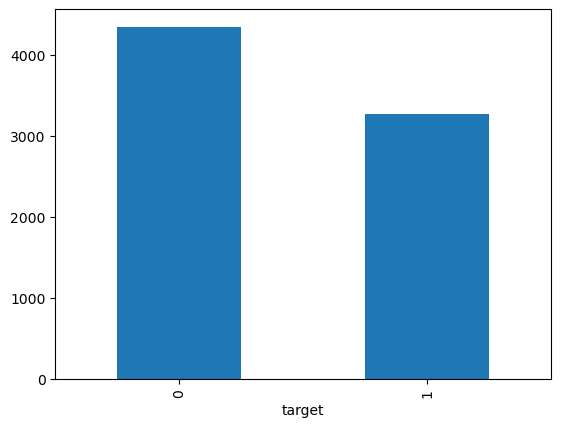

In [6]:
# Hedef değişken dağılımı

print(train["target"].value_counts())

train["target"].value_counts().plot(kind="bar");

In [7]:
# Feature engineering değişkenlerini oluşturalım

train["tweet_length"] = train["text"].str.len()  #Tweet içindeki karakter sayısı.

train["word_count"] = train["text"].apply(lambda x: len(x.split())) #Tweet içindeki kelime sayısı.

train["unique_word_count"] = train["text"].apply(lambda x: len(set(x.split())))  #Tekrarsız kelime sayısı.

train["hashtag_count"] = train["text"].str.count("#") #Etiket sayısı

train["mention_count"] = train["text"].str.count("@")  #Haber ve olay paylaşan kullanıcılar kurumları etiketleyebiliyor.

train["url_count"] = train["text"].str.count("http")  #Gerçek haberlerde kaynak linki paylaşımı daha fazla olabilir.

train["exclamation_count"] = train["text"].str.count("!")  #Acil durum tweetlerinde ünlem sık görülebilir.

train.head()

,id,keyword,location,text,target,tweet_length,word_count,unique_word_count,hashtag_count,mention_count,url_count,exclamation_count
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,69,13,13,1,0,0,0
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38,7,7,0,0,0,0
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,133,22,20,0,0,0,0
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,65,8,8,1,0,0,0
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,88,16,15,2,0,0,0


In [10]:
# Oluşturduğumuz değişkenlerin target'a göre ortalamalarına bakalım

feature_cols = [
    "tweet_length",
    "word_count",
    "unique_word_count",
    "hashtag_count",
    "mention_count",
    "url_count",
    "exclamation_count"
]

train.groupby("target")[feature_cols].mean().T

target,0,1
tweet_length,95.706817,108.113421
word_count,14.704744,15.167533
unique_word_count,14.096499,14.664934
hashtag_count,0.391525,0.520636
mention_count,0.426992,0.276674
url_count,0.507600,0.769795
exclamation_count,0.194150,0.100887


In [13]:
train['text'].sample(10)

2009    Does homeowners insurance cover water damage? ...
2340    Saving the City in Old Town: The Proposed Demo...
6132    Lol '@j2bone: *cousin ' @Foxy__Siren: Coursing...
997     Mopheme and Bigstar Johnson are a problem in t...
5054          Some people are really natural disaster too
5862                     Long Road To Ruin - Foo Fighters
2307    @Flunkie if it makes you feel any better I'm l...
5072    This is the natural and unavoidable consequenc...
4528    UPDATE:M.E. confirms 2 women pulled from burni...
1477    Taylor and Cara aka Catastrophe and Mother Chu...
Name: text, dtype: object

In [14]:
# NLP temizleme fonksiyonu yazıyoruz ve metni düzgün hale getiriyoruz.

import re

def temizle(text):
    
    text = text.lower()
    
    text = re.sub(r"http\S+", "", text)
    
    text = re.sub(r"www\S+", "", text)
    
    text = re.sub(r"@\w+", "", text)
    
    text = re.sub(r"#", "", text)
    
    text = re.sub(r"[^a-z\s]", " ", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

train["clean_text"] = train["text"].apply(temizle)
test["clean_text"] = test["text"].apply(temizle)

train[["text","clean_text"]].head()

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to shelter in place are be...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders in ...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...


In [15]:
# En çok geçen kelimeler

from collections import Counter

tum_kelimeler = " ".join(train["text"]).lower().split()

kelime_sayilari = Counter(tum_kelimeler)

pd.DataFrame(
    kelime_sayilari.most_common(20),
    columns=["Kelime", "Frekans"]
)

,Kelime,Frekans
0,the,3207
1,a,2135
2,in,1949
3,to,1934
4,of,1814
5,and,1405
6,i,1336
7,is,930
8,for,880
9,on,834


In [16]:
# Stopwords yükleme

import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mehmet.sefer.kaya\AppData\Roaming\nltk_data..
[nltk_data]     .
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [17]:
# İngilizce stopwords

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print(list(stop_words)[:20])

['itself', 'by', 'we', 'where', 'herself', 'shouldn', 'its', 'isn', 'most', 'more', 'won', 'y', "we'd", 'ain', "shouldn't", 'can', 'once', "won't", 'doesn', 'hadn']


In [18]:
# Stopwords sonrası en sık kullanılan kelimeler

from collections import Counter

kelimeler = []

for text in train["text"]:
    
    for kelime in text.lower().split():
        
        if kelime not in stop_words:
            kelimeler.append(kelime)

kelime_sayilari = Counter(kelimeler)

pd.DataFrame(
    kelime_sayilari.most_common(30),
    columns=["Kelime", "Frekans"]
)

,Kelime,Frekans
0,-,763
1,like,341
2,&amp;,295
3,get,227
4,new,215
5,??,214
6,via,214
7,fire,209
8,one,179
9,people,174


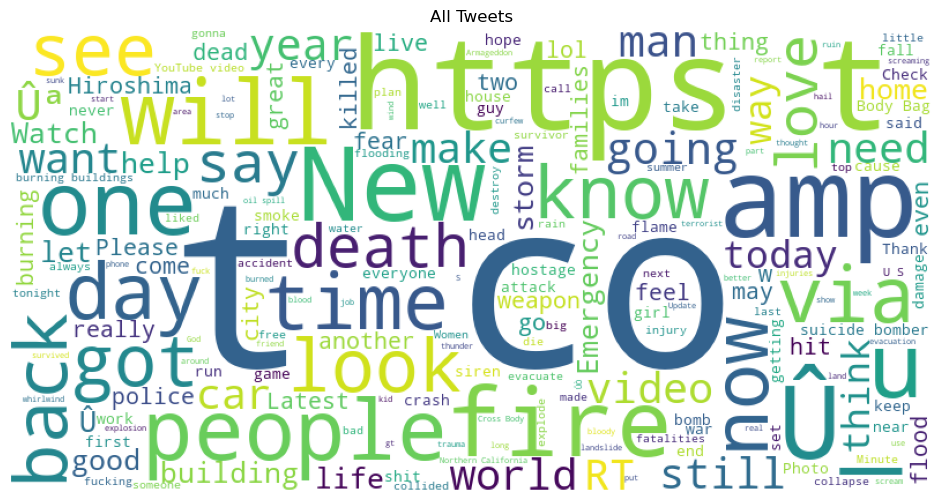

In [19]:
# Tüm tweetler için WordCloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(train["text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("All Tweets")
plt.show()

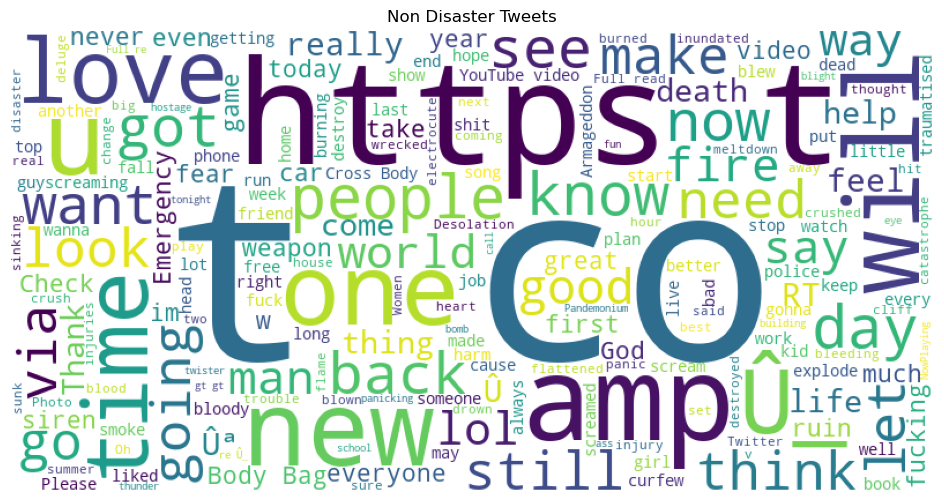

In [20]:
# Afet olmayan tweetler

text = " ".join(train[train["target"] == 0]["text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Non Disaster Tweets")
plt.show()

In [21]:
# Tekrar NLP temizleme

import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def temizle(text):

    text = text.lower()

    text = re.sub(r"http\S+", " ", text)

    text = re.sub(r"www\S+", " ", text)

    text = re.sub(r"@\w+", " ", text)

    text = re.sub(r"&amp;", " ", text)

    text = re.sub(r"rt", " ", text)

    text = re.sub(r"[^a-z\s]", " ", text)

    kelimeler = [
        kelime for kelime in text.split()
        if kelime not in stop_words
    ]

    return " ".join(kelimeler)

train["clean_text"] = train["text"].apply(temizle)
test["clean_text"] = test["text"].apply(temizle)

train[["text", "clean_text"]].head()

,text,clean_text
0,Our Deeds are the Reason of this #earthquake M...,deeds reason ea hquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfires pou...


In [22]:
# Train ve validation ayıralım

from sklearn.model_selection import train_test_split

x_train, x_valid, y_train, y_valid = train_test_split(
    train["clean_text"],
    train["target"],
    test_size=0.20,
    random_state=42,
    stratify=train["target"]
)

print("Train:", x_train.shape)
print("Validation:", x_valid.shape)

Train: (6090,)
Validation: (1523,)


In [23]:
# TF-IDF dönüşümü

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

x_train_tfidf = tfidf.fit_transform(x_train)

x_valid_tfidf = tfidf.transform(x_valid)

print(x_train_tfidf.shape)
print(x_valid_tfidf.shape)

(6090, 5000)
(1523, 5000)


In [24]:
# Logistic Regression modeli

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(x_train_tfidf, y_train)

y_pred = model.predict(x_valid_tfidf)

In [25]:
# Model performansı

from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix)

print("Accuracy :", accuracy_score(y_valid, y_pred))
print("F1 Score :", f1_score(y_valid, y_pred))

print("\nClassification Report\n")
print(classification_report(y_valid, y_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_valid, y_pred))

Accuracy : 0.824688115561392
F1 Score : 0.7780548628428927

Classification Report

              precision    recall  f1-score   support

           0       0.81      0.91      0.86       869
           1       0.85      0.72      0.78       654

    accuracy                           0.82      1523
   macro avg       0.83      0.81      0.82      1523
weighted avg       0.83      0.82      0.82      1523


Confusion Matrix

[[788  81]
 [186 468]]


In [26]:
# Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(x_train_tfidf, y_train)

nb_pred = nb_model.predict(x_valid_tfidf)

print("Accuracy :", accuracy_score(y_valid, nb_pred))
print("F1 Score :", f1_score(y_valid, nb_pred))

Accuracy : 0.8220617202889035
F1 Score : 0.7697536108751062


In [29]:
# Test verisini dönüştürelim

test_tfidf = tfidf.transform(test["clean_text"])

test_pred = model.predict(test_tfidf)

submission = pd.DataFrame({
    "id": test["id"],
    "target": test_pred
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,target
0,0,1
1,2,1
2,3,1
3,9,1
4,11,1


### Şimdi modeli biraz geliştirmek için featurları kullanacağız.

In [27]:
# Keyword sütunundaki en sık değerler

train["keyword"].value_counts().head(20)

keyword
fatalities     45
deluge         42
armageddon     42
damage         41
body%20bags    41
harm           41
sinking        41
evacuate       40
outbreak       40
fear           40
siren          40
windstorm      40
collided       40
twister        40
hellfire       39
famine         39
flames         39
weapon         39
wreckage       39
sunk           39
Name: count, dtype: int64

In [28]:
# Keyword bazında afet oranları

keyword_target = train.groupby("keyword")["target"].mean()

keyword_target.sort_values(ascending=False).head(20)

keyword
derailment               1.000000
debris                   1.000000
wreckage                 1.000000
outbreak                 0.975000
typhoon                  0.973684
oil%20spill              0.973684
suicide%20bombing        0.969697
suicide%20bomber         0.967742
bombing                  0.931034
rescuers                 0.914286
suicide%20bomb           0.914286
nuclear%20disaster       0.911765
evacuated                0.888889
razed                    0.885714
wildfire                 0.878788
wild%20fires             0.870968
airplane%20accident      0.857143
mass%20murder            0.848485
buildings%20on%20fire    0.848485
forest%20fires           0.843750
Name: target, dtype: float64

In [30]:
# Test verisi içinde aynı feature engineering sütunlarını oluşturuyoruz.

test["tweet_length"] = test["text"].str.len()

test["word_count"] = test["text"].apply(lambda x: len(x.split()))

test["unique_word_count"] = test["text"].apply(
    lambda x: len(set(x.split()))
)

test["hashtag_count"] = test["text"].str.count("#")

test["mention_count"] = test["text"].str.count("@")

test["url_count"] = test["text"].str.count("http")

test["exclamation_count"] = test["text"].str.count("!")

In [31]:
# Keyword sütununu metne ekleyelim

train["keyword"] = train["keyword"].fillna("unknown")
test["keyword"] = test["keyword"].fillna("unknown")

train["text_with_keyword"] = train["keyword"] + " " + train["clean_text"]
test["text_with_keyword"] = test["keyword"] + " " + test["clean_text"]

train[["keyword", "clean_text", "text_with_keyword"]].head()

,keyword,clean_text,text_with_keyword
0,unknown,deeds reason ea hquake may allah forgive us,unknown deeds reason ea hquake may allah forgi...
1,unknown,forest fire near la ronge sask canada,unknown forest fire near la ronge sask canada
2,unknown,residents asked shelter place notified officer...,unknown residents asked shelter place notified...
3,unknown,people receive wildfires evacuation orders cal...,unknown people receive wildfires evacuation or...
4,unknown,got sent photo ruby alaska smoke wildfires pou...,unknown got sent photo ruby alaska smoke wildf...


In [32]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 7613 non-null   int64 
 1   keyword            7613 non-null   object
 2   location           5080 non-null   object
 3   text               7613 non-null   object
 4   target             7613 non-null   int64 
 5   tweet_length       7613 non-null   int64 
 6   word_count         7613 non-null   int64 
 7   unique_word_count  7613 non-null   int64 
 8   hashtag_count      7613 non-null   int64 
 9   mention_count      7613 non-null   int64 
 10  url_count          7613 non-null   int64 
 11  exclamation_count  7613 non-null   int64 
 12  clean_text         7613 non-null   object
 13  text_with_keyword  7613 non-null   object
dtypes: int64(9), object(5)
memory usage: 832.8+ KB


In [33]:
# Sayısal ve kategorik sütunları ayrı ayrı modele eklemek üzere değişkenlere atıyoruz.
x_text = train["text_with_keyword"]

x_numeric = train[
    [
        "tweet_length",
        "word_count",
        "unique_word_count",
        "hashtag_count",
        "mention_count",
        "url_count",
        "exclamation_count"
    ]
]

y = train["target"]

In [34]:
x_text_train, x_text_valid, x_num_train, x_num_valid, y_train, y_valid = train_test_split(x_text,x_numeric,y,test_size=0.20,random_state=42,stratify=y)

In [35]:
# TF-IDF dönüşümü yapalım

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_v2 = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1, 2)
)

x_text_train_tfidf = tfidf_v2.fit_transform(x_text_train)
x_text_valid_tfidf = tfidf_v2.transform(x_text_valid)

print(x_text_train_tfidf.shape)
print(x_text_valid_tfidf.shape)

(6090, 7000)
(1523, 7000)


In [39]:
#Sayısal değişkenleri scale ediyoruz.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_num_train_scaled = scaler.fit_transform(x_num_train)
x_num_valid_scaled = scaler.transform(x_num_valid)

In [40]:
# Metin ve sayısal değişkenleri birleştirelim

from scipy.sparse import hstack

x_train_full = hstack([x_text_train_tfidf, x_num_train_scaled])
x_valid_full = hstack([x_text_valid_tfidf, x_num_valid_scaled])

print(x_train_full.shape)
print(x_valid_full.shape)

(6090, 7007)
(1523, 7007)


In [41]:
# Logistic Regression V2 modeli

from sklearn.linear_model import LogisticRegression

model_v2 = LogisticRegression(max_iter=1000)

model_v2.fit(x_train_full, y_train)

y_pred_v2 = model_v2.predict(x_valid_full)

In [42]:
# V2 model performansı

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("Accuracy :", accuracy_score(y_valid, y_pred_v2))
print("F1 Score :", f1_score(y_valid, y_pred_v2))

print("\nClassification Report\n")
print(classification_report(y_valid, y_pred_v2))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_valid, y_pred_v2))

Accuracy : 0.8122127380170716
F1 Score : 0.7689822294022617

Classification Report

              precision    recall  f1-score   support

           0       0.81      0.88      0.84       869
           1       0.82      0.73      0.77       654

    accuracy                           0.81      1523
   macro avg       0.81      0.80      0.81      1523
weighted avg       0.81      0.81      0.81      1523


Confusion Matrix

[[761 108]
 [178 476]]


In [43]:
# Linear SVC modeli

from sklearn.svm import LinearSVC

svc_model = LinearSVC(
    random_state=42
)

svc_model.fit(x_train_tfidf, y_train)

svc_pred = svc_model.predict(x_valid_tfidf)

In [44]:
# Linear SVC performansı

from sklearn.metrics import accuracy_score, f1_score

print("Accuracy :", accuracy_score(y_valid, svc_pred))
print("F1 Score :", f1_score(y_valid, svc_pred))

Accuracy : 0.7997373604727511
F1 Score : 0.7596532702915682


In [47]:
# Farklı modelleri karşılaştıralım

import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import PassiveAggressiveClassifier, RidgeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Logistic Regression C=0.5": LogisticRegression(max_iter=1000, C=0.5),
    "Logistic Regression C=2": LogisticRegression(max_iter=1000, C=2),
    "Linear SVC": LinearSVC(random_state=42),
    "Multinomial NB": MultinomialNB(),
    "Bernoulli NB": BernoulliNB(),
    "Passive Aggressive": PassiveAggressiveClassifier(random_state=42),
    "Ridge Classifier": RidgeClassifier()
}

results = []

for name, model in models.items():
    
    model.fit(x_train_tfidf, y_train)
    
    pred = model.predict(x_valid_tfidf)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_valid, pred),
        "Precision": precision_score(y_valid, pred),
        "Recall": recall_score(y_valid, pred),
        "F1": f1_score(y_valid, pred)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.824688,0.852459,0.715596,0.778055
2,Logistic Regression C=2,0.820092,0.831010,0.729358,0.776873
4,Multinomial NB,0.822062,0.866157,0.692661,0.769754
7,Ridge Classifier,0.810900,0.807047,0.735474,0.769600
1,Logistic Regression C=0.5,0.815496,0.857965,0.683486,0.760851
3,Linear SVC,0.799737,0.783740,0.737003,0.759653
5,Bernoulli NB,0.810243,0.892473,0.634557,0.741734
6,Passive Aggressive,0.731451,0.682563,0.700306,0.691321


Model başarısını yükseltmek için tekrar modeli güçlendirmeye çalışacağız.

In [48]:
# Yeni TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

x_train_tfidf = tfidf.fit_transform(x_train)
x_valid_tfidf = tfidf.transform(x_valid)

model = LogisticRegression(max_iter=1000)

model.fit(x_train_tfidf, y_train)

pred = model.predict(x_valid_tfidf)

print("Accuracy :", accuracy_score(y_valid, pred))
print("F1 :", f1_score(y_valid, pred))

Accuracy : 0.8240315167432699
F1 : 0.7770382695507487


In [50]:
# Voting Ensemble modeli

from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

voting_model = VotingClassifier(
    estimators=[
        ("logistic", LogisticRegression(max_iter=1000)),
        ("nb", MultinomialNB())
    ],
    voting="soft"
)

voting_model.fit(x_train_tfidf, y_train)

voting_pred = voting_model.predict(x_valid_tfidf)

print("Accuracy :", accuracy_score(y_valid, voting_pred))
print("F1 :", f1_score(y_valid, voting_pred))

print("\nClassification Report\n")
print(classification_report(y_valid, voting_pred))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_valid, voting_pred))

Accuracy : 0.8233749179251477
F1 : 0.7718405428329093

Classification Report

              precision    recall  f1-score   support

           0       0.80      0.92      0.86       869
           1       0.87      0.70      0.77       654

    accuracy                           0.82      1523
   macro avg       0.83      0.81      0.81      1523
weighted avg       0.83      0.82      0.82      1523


Confusion Matrix

[[799  70]
 [199 455]]


In [52]:
#Şimdi en iyi skor veren logistic regression modelini tüm train verisi üzerinde yeniden eğitip test seti için submission oluşturalım.
# Nihai model için train ve test verilerini hazırlayalım

x_full = train["clean_text"]
y_full = train["target"]

x_test = test["clean_text"]

In [53]:
# Nihai TF-IDF dönüşümü

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_final = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

x_full_tfidf = tfidf_final.fit_transform(x_full)
x_test_tfidf = tfidf_final.transform(x_test)

print(x_full_tfidf.shape)
print(x_test_tfidf.shape)

(7613, 5000)
(3263, 5000)


In [54]:
# Nihai Logistic Regression modeli

from sklearn.linear_model import LogisticRegression

final_model = LogisticRegression(
    max_iter=1000
)

final_model.fit(x_full_tfidf, y_full)

LogisticRegression(max_iter=1000)

In [55]:
# Test tahminleri

test_pred = final_model.predict(x_test_tfidf)

test_pred[:10]

array([1, 1, 1, 0, 1, 1, 0, 0, 0, 0])

In [56]:
# Submission dosyası oluşturalım

submission = pd.DataFrame({
    "id": test["id"],
    "target": test_pred
})

submission.head()

,id,target
0,0,1
1,2,1
2,3,1
3,9,0
4,11,1


In [57]:
# CSV olarak kaydedelim

submission.to_csv(
    "submission_final.csv",
    index=False
)

print("Submission hazır.")

Submission hazır.


In [58]:
# Son kontrol

submission.shape

(3263, 2)

Yapılan denemeler sonucunda en iyi performans TF-IDF tabanlı Logistic Regression modeliyle alınmıştır. Model validation setinde 0.7781 F1 skoruna ulaşmış, Kaggle public leaderboard üzerinde ise nihai submission ile 0.79987 skor elde edilmiştir. Keyword ekleme, sayısal tweet özellikleri ve farklı algoritmalar denenmiş ancak Logistic Regression modelini geçememiştir. Bu nedenle final model olarak TF-IDF + Logistic Regression yaklaşımı seçilmiştir.

In [59]:
# Nihai model ve TF-IDF nesnesini kaydedelim

import joblib

joblib.dump(final_model, "disaster_tweet_model.pkl")
joblib.dump(tfidf_final, "tfidf_vectorizer.pkl")

print("Model ve TF-IDF başarıyla kaydedildi.")

Model ve TF-IDF başarıyla kaydedildi.
